# 05 — Interpretabilidade (SHAP)

**Objetivo:** Explicar o modelo com SHAP (TreeExplainer), validar que as features importantes convergem com a EDA (V14 > V4 > V12) e analisar casos individuais (fraude detectada vs camuflada) para expor o teto estrutural de recall.

---

**Roteiro:**

1. Setup
2. Preparação dos Dados para Interpretação com SHAP
3. SHAP Summary (importância global)
4. Casos individuais: fraude detectada vs falso negativo
5. Fechamento


### Etapa 1 - Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from src.config import CONFIG, CAMINHOS
from src.viz_config import aplicar_tema_seaborn, PALETTE, CORES

DADOS_PRO    = CAMINHOS.dados_processed
MODELS_DIR   = CAMINHOS.modelos
FIGURAS_DIR  = CAMINHOS.figures
RANDOM_STATE = CONFIG["dados"]["random_state"]

aplicar_tema_seaborn()

print("\n✅ Setup configurado!\n")

print(f"SEED             : {RANDOM_STATE}")
print(f"FIGURAS          : {FIGURAS_DIR}")
print(f"MODELOS          : {MODELS_DIR}")
print(f"DADOS PROCESSADOS: {DADOS_PRO}")


✅ Setup configurado!

SEED             : 42
FIGURAS          : C:\Users\jas_t\Repo\Portfolios\credit_card_fraud\reports\figures
MODELOS          : C:\Users\jas_t\Repo\Portfolios\credit_card_fraud\models
DADOS PROCESSADOS: C:\Users\jas_t\Repo\Portfolios\credit_card_fraud\data\processed


### Etapa 2 -Preparação dos Dados para Interpretação com SHAP

Nesta etapa, serão carregados os artefatos necessários para a interpretação do modelo final com **SHAP**.

O processo será organizado em quatro passos:

1. **Carregamento do pipeline, dados e metadados:**
   Serão carregados o pipeline final treinado, o conjunto de teste e as informações auxiliares do projeto, como nomes das features e configurações utilizadas.

2. **Separação do pré-processador e do modelo:**
   O pipeline será decomposto em seus dois principais componentes:

   * `preprocessor`: responsável pelas transformações aplicadas às features;
   * `model`: estimador final, neste caso o **XGBoost otimizado**.

3. **Transformação do conjunto de teste:**
   O `X_test` será transformado pelo pré-processador, garantindo que os dados estejam no mesmo formato utilizado pelo modelo durante a predição.

   Essa etapa é necessária porque o SHAP deve operar sobre as **features efetivamente vistas pelo modelo**, e não sobre os dados brutos originais.

4. **Criação do TreeExplainer:**
   Será utilizado o **TreeExplainer**, método adequado para modelos baseados em árvores, como o XGBoost.

In [2]:
pipeline_final = joblib.load(MODELS_DIR / "pipeline_final.joblib")

X_test = pd.read_parquet(DADOS_PRO / "X_test.parquet")
y_test = pd.read_parquet(DADOS_PRO / "y_test.parquet").iloc[:, 0]

meta   = json.load(open(MODELS_DIR / "metadados.json", encoding="utf-8"))

THRESHOLD = meta["threshold"]

print(f"Threshold do modelo: {THRESHOLD:.3f}")

Threshold do modelo: 0.264


In [3]:
preprocessor = pipeline_final.named_steps["prep"]
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('amount', ...), ('vs', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g.

In [4]:
modelo = pipeline_final.named_steps["clf"]
modelo

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8562435165095661
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [5]:
X_test_proc = preprocessor.transform(X_test)

print(f"Tipo: {type(X_test_proc).__name__} · shape {X_test_proc.shape}")
print(f"Features nomeadas: {hasattr(X_test_proc, 'columns')}")

Tipo: DataFrame · shape (56746, 29)
Features nomeadas: True


In [6]:
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test_proc)

print(f"SHAP values calculados: {shap_values.shape}")

SHAP values calculados: (56746, 29)


### Etapa 3 - SHAP Summary (importância global)

Nesta etapa, será calculada a importância média absoluta dos valores SHAP para cada feature.

A métrica utilizada será a média de |SHAP|, que representa o impacto médio de cada variável nas previsões do modelo, independentemente da direção do efeito.

In [7]:
feature_names = list(X_test_proc.columns)

In [8]:
shap_imp = pd.DataFrame({
    "feature": feature_names,
    "shap_medio": np.abs(shap_values).mean(axis=0),
}).sort_values("shap_medio", ascending=False)

print("═" * 60)
print("TOP 10 FEATURES — IMPORTÂNCIA SHAP (média |SHAP|)")
print("═" * 60)

for _, r in shap_imp.head(10).iterrows():
    print(f"   {r['feature']:<10}: {r['shap_medio']:.4f}")

════════════════════════════════════════════════════════════
TOP 10 FEATURES — IMPORTÂNCIA SHAP (média |SHAP|)
════════════════════════════════════════════════════════════
   V14       : 3.3310
   V4        : 2.9339
   V12       : 1.6394
   V3        : 1.3010
   V11       : 1.2851
   V10       : 1.1557
   V8        : 0.7702
   V1        : 0.6933
   V26       : 0.6137
   Amount    : 0.5685


Será realizada uma validação cruzada conceitual entre os resultados de **SHAP** e os testes estatísticos aplicados na EDA com **Mann-Whitney U**.

O objetivo é verificar se as features consideradas mais relevantes pelo modelo também foram aquelas que apresentaram maior separação estatística entre transações legítimas e fraudulentas.

A comparação considera duas perspectivas complementares:

* **Mann-Whitney U**: avalia a separação univariada entre as classes, feature por feature;
* **SHAP**: mede a contribuição de cada variável dentro do modelo treinado, considerando interações e relações não lineares capturadas pelo XGBoost.

In [9]:
top_eda  = ["V14", "V4", "V12", "V11", "V10", "V3", "V2", "V16", "V9", "V7"]
top_shap = shap_imp.head(10)["feature"].tolist()
em_comum = set(top_eda) & set(top_shap)

print(f"Top 10 EDA (Mann-Whitney) ∩ Top 10 SHAP: {len(em_comum)} em comum → {sorted(em_comum)}\n")
print(f"(convergência entre estatística univariada e o modelo)")

Top 10 EDA (Mann-Whitney) ∩ Top 10 SHAP: 6 em comum → ['V10', 'V11', 'V12', 'V14', 'V3', 'V4']

(convergência entre estatística univariada e o modelo)


Nesta etapa, será gerada a visualização **Beeswarm** dos valores SHAP.

Esse gráfico é uma das formas mais informativas de interpretar modelos supervisionados, pois combina **importância global** e **direção do efeito** de cada feature em uma única visualização.

No Beeswarm:

* cada ponto representa uma observação do conjunto analisado;
* a posição no eixo X indica o impacto da feature na predição do modelo;
* valores SHAP positivos empurram a previsão em direção à classe **fraude**;
* valores SHAP negativos reduzem essa probabilidade;
* a cor dos pontos representa o valor da feature, permitindo identificar se valores altos ou baixos estão associados a maior risco.


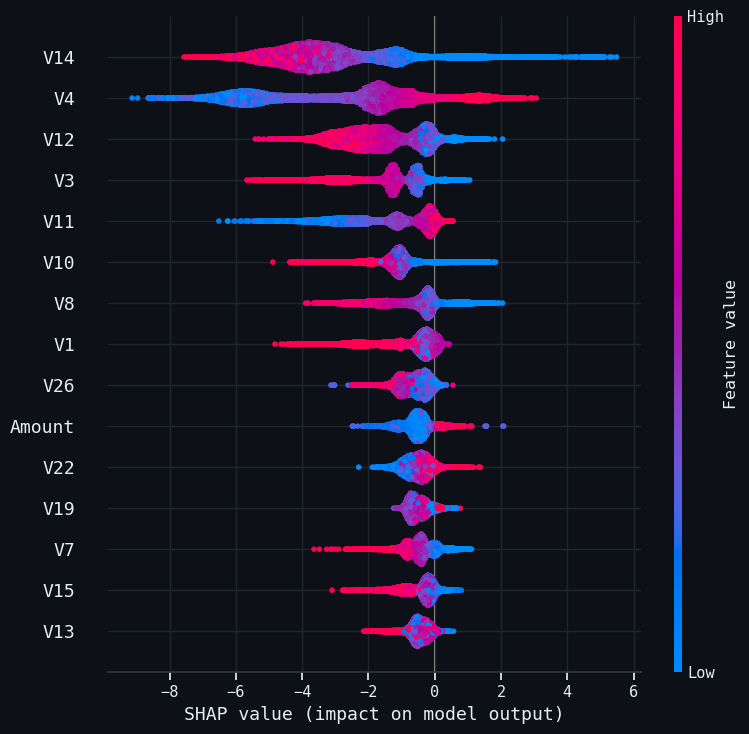

In [10]:
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_proc, max_display=15, show=False)
fig = plt.gcf()
fig.patch.set_facecolor(CORES["fundo"])
for ax in fig.axes:
    ax.set_facecolor(CORES["fundo"])
    ax.tick_params(colors=CORES["texto"])
    ax.xaxis.label.set_color(CORES["texto"])
    ax.yaxis.label.set_color(CORES["texto"])
    for spine in ax.spines.values():
        spine.set_color(CORES["borda"])
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "nb05_shap_summary.png", dpi=120,
            bbox_inches="tight", facecolor=CORES["fundo"])
plt.show()

**Validação entre EDA e SHAP**

A comparação entre os resultados da **EDA com Mann-Whitney** e a interpretação do modelo via **SHAP** mostrou forte consistência entre os métodos.

Entre as 10 features mais relevantes, **6 aparecem em ambas as análises**:

* `V14`
* `V4`
* `V12`
* `V3`
* `V11`
* `V10`

Além da interseção, a hierarquia das principais variáveis também foi muito semelhante. O teste Mann-Whitney indicou `V14`, `V4` e `V12` como as três features mais discriminativas, e o SHAP colocou exatamente essas mesmas variáveis no topo da importância global.

Esse alinhamento fortalece a interpretação do modelo, pois combina duas abordagens independentes:

* **Mann-Whitney**: mede separação estatística univariada entre fraude e transação legítima;
* **SHAP**: mede o impacto das variáveis nas previsões do XGBoost, considerando o comportamento aprendido pelo modelo.

A concordância entre os métodos sugere que os principais sinais usados pelo modelo não são artefatos do algoritmo, mas refletem padrões reais presentes nos dados.

**Interpretação do Beeswarm**

O gráfico Beeswarm ajuda a entender a direção dos efeitos das principais features.

Em `V14`, valores baixos aparecem associados a valores SHAP positivos, empurrando a previsão em direção à classe **fraude**. Esse comportamento é coerente com a EDA, na qual a mediana de `V14` para fraudes era significativamente menor.

Já em `V4`, o padrão é oposto: valores altos contribuem positivamente para a probabilidade de fraude, também em linha com a análise exploratória, que mostrou valores maiores dessa variável entre transações fraudulentas.

**Divergências entre os Métodos**

As diferenças entre os rankings também são informativas. Features como `V8`, `V1`, `V26` e `Amount` aparecem com maior relevância no SHAP, enquanto outras variáveis tinham maior destaque no Mann-Whitney.

Isso é esperado, pois o Mann-Whitney avalia cada variável isoladamente, enquanto o XGBoost pode capturar **interações não lineares** entre features.

Um exemplo importante é `Amount`, que teve efeito univariado modesto na EDA, mas apareceu entre as 10 variáveis mais importantes no SHAP. Isso sugere que o valor da transação, embora fraco isoladamente, agrega sinal preditivo quando combinado com as variáveis anonimizadas `V`.

De forma geral, a análise confirma que o modelo está aprendendo padrões estatisticamente consistentes e, ao mesmo tempo, explorando interações adicionais relevantes para a detecção de fraudes.

### Etapa 4 - Casos individuais: fraude detectada vs falso negativo

In [11]:
y_proba = pipeline_final.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= THRESHOLD).astype(int)

idx_tp = np.where((y_test.values == 1) & (y_pred == 1))[0]
idx_fn = np.where((y_test.values == 1) & (y_pred == 0))[0]
caso_tp = idx_tp[np.argmax(y_proba[idx_tp])]
caso_fn = idx_fn[np.argmin(y_proba[idx_fn])] if len(idx_fn) > 0 else None

In [12]:
def waterfall_moderno(idx, titulo, nome_arquivo):
    expl = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_proc.iloc[idx].values,
        feature_names=feature_names,
    )
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(expl, max_display=12, show=False)
    fig = plt.gcf()
    fig.patch.set_facecolor(CORES["fundo"])
    for ax in fig.axes:
        ax.set_facecolor(CORES["fundo"])
        ax.tick_params(colors=CORES["texto"])
        for t in ax.texts:
            t.set_color(CORES["texto"])
        for spine in ax.spines.values():
            spine.set_color(CORES["borda"])
    plt.title(titulo, color=CORES["texto"], pad=20)
    fig.tight_layout()
    fig.savefig(FIGURAS_DIR / nome_arquivo, dpi=120,
                bbox_inches="tight", facecolor=CORES["fundo"])
    plt.show()

TP: fraude detectada

TP: índice 18427, P=1.000
   V14=-13.69  V4=8.93  V12=-13.06


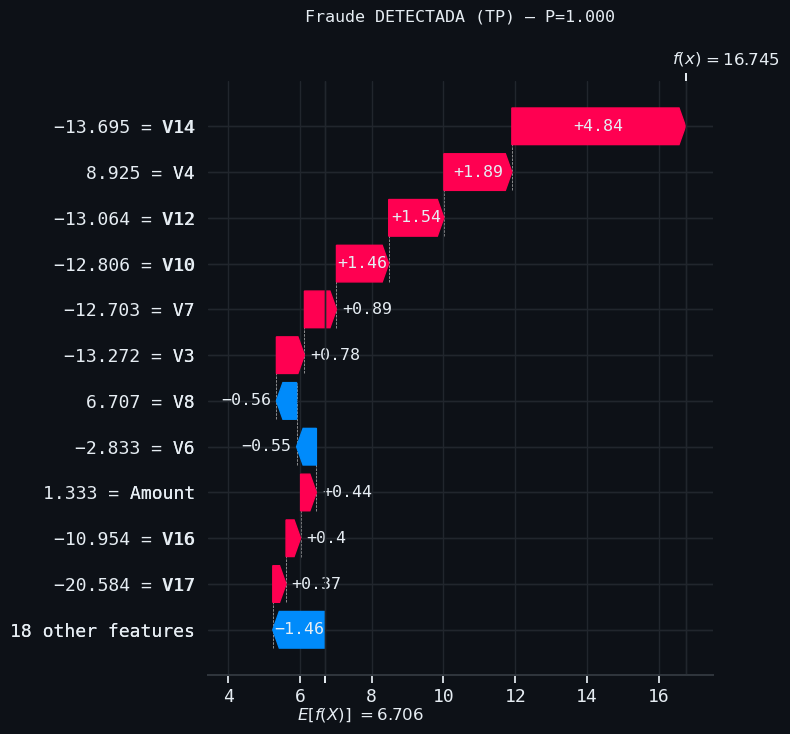

In [13]:
print(f"TP: índice {caso_tp}, P={y_proba[caso_tp]:.3f}")
print(f"   V14={X_test_proc.iloc[caso_tp]['V14']:.2f}  "
      f"V4={X_test_proc.iloc[caso_tp]['V4']:.2f}  "
      f"V12={X_test_proc.iloc[caso_tp]['V12']:.2f}")
waterfall_moderno(caso_tp, f"Fraude DETECTADA (TP) — P={y_proba[caso_tp]:.3f}",
                  "nb05_waterfall_tp.png")

FN: fraude que escapou


FN: índice 5187, P=0.000
   V14=-0.01  V4=0.90  V12=0.69


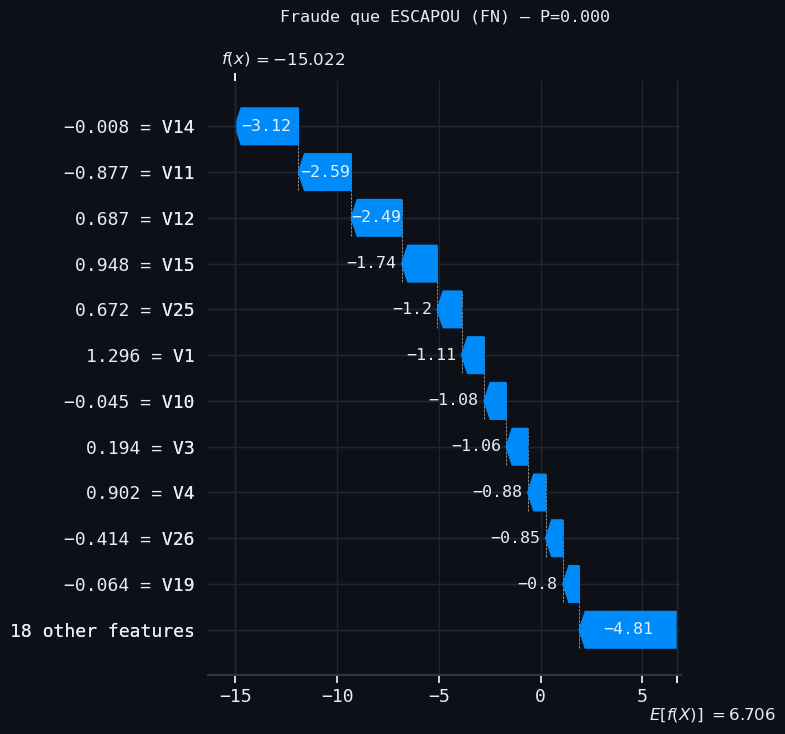

In [14]:
if caso_fn is not None:
    print(f"\nFN: índice {caso_fn}, P={y_proba[caso_fn]:.3f}")
    print(f"   V14={X_test_proc.iloc[caso_fn]['V14']:.2f}  "
          f"V4={X_test_proc.iloc[caso_fn]['V4']:.2f}  "
          f"V12={X_test_proc.iloc[caso_fn]['V12']:.2f}")
    waterfall_moderno(caso_fn, f"Fraude que ESCAPOU (FN) — P={y_proba[caso_fn]:.3f}",
                      "nb05_waterfall_fn.png")

A análise dos gráficos **Waterfall** permite comparar dois casos extremos do modelo: uma fraude corretamente detectada (**TP**) e uma fraude não detectada (**FN**).

O contraste entre os dois exemplos confirma a principal hipótese observada ao longo do projeto: o modelo identifica muito bem fraudes com assinatura estatística extrema, mas encontra dificuldade em fraudes que se parecem com transações legítimas.

**Fraude Detectada — True Positive**

No caso corretamente classificado como fraude, o modelo atribuiu probabilidade praticamente máxima:

* **Probabilidade prevista:** `P = 1,000`
* **Valor final do modelo:** `f(x) = 16,7`
* **Base do modelo:** `E[f(X)] = 6,7`

As principais features empurraram fortemente a previsão em direção à classe fraude:

* `V14`: contribuição SHAP **+4,84** | valor observado **−13,69**
* `V4`: contribuição SHAP **+1,89** | valor observado **8,93**
* `V12`: contribuição SHAP **+1,54** | valor observado **−13,06**

Esses valores são extremamente distantes do padrão observado em transações legítimas, especialmente em `V14` e `V12`, que aparecem com valores muito negativos.

Esse caso representa uma fraude de assinatura clara: as mesmas variáveis apontadas como relevantes pela EDA, pelo Mann-Whitney e pelo SHAP global aparecem aqui com valores extremos, levando o modelo a uma decisão praticamente certa.

**Fraude Não Detectada — False Negative**

No caso não detectado, a transação era uma fraude real, mas foi classificada como legítima:

* **Probabilidade prevista:** `P = 0,000`
* **Valor final do modelo:** `f(x) = -15,0`

As principais features não apresentaram o padrão extremo típico das fraudes detectadas:

* `V14`: valor observado **−0,01**
* `V4`: valor observado **0,90**
* `V12`: valor observado **0,69**

O ponto mais relevante é `V14`: enquanto fraudes detectadas apresentam valores muito negativos nessa variável, este caso possui `V14 ≈ 0`, valor praticamente indistinguível do comportamento típico de transações legítimas.

Como resultado, as contribuições SHAP empurraram a previsão para a classe legítima. O modelo não encontrou sinal estatístico suficiente para classificar a transação como fraude.

### Etapa 5 - Fechamento

**MÉTODO**
* TreeExplainer (exato para XGBoost) sobre os 56.746 do teste

**IMPORTÂNCIA GLOBAL (SHAP)**
* Top: V14 (3.33), V4 (2.93), V12 (1.64), V3, V11, V10
* Amount no top 10 — usado em INTERAÇÃO (fraco sozinho na EDA)

**VALIDAÇÃO CRUZADA (SHAP vs Mann-Whitney da EDA)**
* 6/10 features em comum, TOPO idêntico (V14 > V4 > V12)
* Estatística univariada e modelo convergem → robustez

**CASOS INDIVIDUAIS (o par que explica o recall ~80%)**
* TP detectada (P=1.000): V14=-13.7, V12=-13.1 → padrão extremo
* FN escapou (P=0.000):   V14=-0.01, V4=0.90  → camuflada (~normal)
* Os 20% que escapam = fraudes desenhadas p/ imitar legítimas
    (limite estrutural do problema, não falha de ajuste)

**NOTA: features anonimizadas (PCA) → interpretação técnica
  (quais dimensões pesam), não semântica (o que significam)**

**ARTEFATOS**
* nb05_shap_summary.png
* nb05_waterfall_tp.png · nb05_waterfall_fn.png

**PRÓXIMO PASSO → NB06 (Relatório Final)**
* Consolidar artefatos · teste de integridade · relatório HTML